## Experiment No: 10
## Experiment Title: Mini Project - AI-Powered News Article Summarizer

**Name:** Himanshu Jadhav  
**Roll Number:** TE-32

### Step 1: Setup and Libraries

In [1]:
# Core libraries
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NLP libraries
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

# Optional third-party packages, imported defensively
TRANSFORMERS_AVAILABLE = True
try:
    from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
except ImportError:
    TRANSFORMERS_AVAILABLE = False
    print("[WARNING] 'transformers' (and/or 'torch') is not installed.")
    print("          Install with: pip install transformers torch")

ROUGE_AVAILABLE = True
try:
    from rouge_score import rouge_scorer
except ImportError:
    ROUGE_AVAILABLE = False
    print("[WARNING] 'rouge_score' is not installed.")
    print("          Install with: pip install rouge_score")

for resource in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)

### Step 2: Input — Small News Article Dataset


In [2]:
articles = [
    {
        "title": "Tech Company Launches New AI Model",
        "text": """A leading technology company announced the release of its newest
        artificial intelligence model this week. The model is designed to improve
        natural language understanding and can generate human-like text responses.
        Company executives said the new system outperforms previous versions on
        several benchmark tests. The model will be available to developers through
        an API starting next month. Analysts believe this launch could intensify
        competition among major AI companies. Early testers have praised the model
        for its speed and accuracy in handling complex queries.""",
        "reference": "A tech company launched a new AI model that outperforms previous versions and will be available via API next month."
    },
    {
        "title": "City Announces New Public Transport Plan",
        "text": """The city council approved a new public transportation plan aimed at
        reducing traffic congestion. The plan includes the construction of two new
        metro lines and expansion of the existing bus network. Officials said the
        project will take five years to complete and cost several million dollars.
        Residents have expressed mixed reactions, with some welcoming the improved
        connectivity and others concerned about construction disruptions. The first
        phase of construction is expected to begin early next year.""",
        "reference": "The city approved a five-year public transport plan with new metro lines and expanded buses to reduce traffic congestion."
    }
]

news_df = pd.DataFrame(articles)
print(f"Number of articles: {len(news_df)}")
news_df[["title", "reference"]]

Number of articles: 2


,title,reference
0,Tech Company Launches New AI Model,A tech company launched a new AI model that ou...
1,City Announces New Public Transport Plan,The city approved a five-year public transport...


### Step 3: Preprocessing — Text Cleaning


In [3]:
def clean_text(text):
    """Collapse repeated whitespace/newlines and strip leading/trailing space."""
    return re.sub(r"\s+", " ", text).strip()

news_df["text"] = news_df["text"].apply(clean_text)
news_df[["title", "text"]].head()

,title,text
0,Tech Company Launches New AI Model,A leading technology company announced the rel...
1,City Announces New Public Transport Plan,The city council approved a new public transpo...


### Step 4: Dataset Overview


In [4]:
news_df["num_sentences"] = news_df["text"].apply(lambda t: len(sent_tokenize(t)))
news_df["num_words"] = news_df["text"].apply(lambda t: len(t.split()))
news_df[["title", "num_sentences", "num_words"]]

,title,num_sentences,num_words
0,Tech Company Launches New AI Model,6,82
1,City Announces New Public Transport Plan,5,75


**Visualization 1 — Dataset Overview:** number of sentences and number of words per article, side by side.

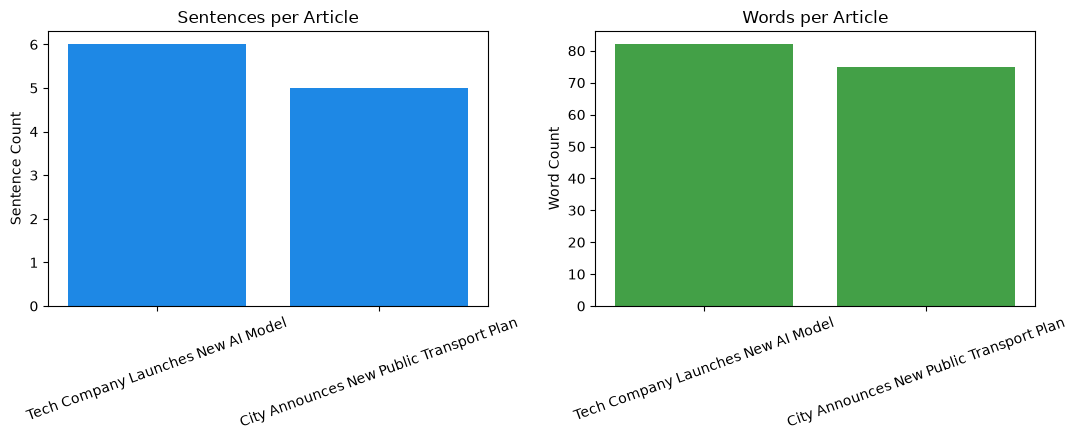

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(news_df["title"], news_df["num_sentences"], color="#1E88E5")
axes[0].set_title("Sentences per Article")
axes[0].set_ylabel("Sentence Count")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(news_df["title"], news_df["num_words"], color="#43A047")
axes[1].set_title("Words per Article")
axes[1].set_ylabel("Word Count")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Step 5: Extractive Summarization Function (TF-IDF)


In [6]:
def extractive_summary(text, num_sentences=2):
    """Return the top `num_sentences` sentences of `text`, ranked by summed TF-IDF weight."""
    sentences = sent_tokenize(text)
    if len(sentences) <= num_sentences:
        return text

    vectorizer = TfidfVectorizer(stop_words="english")
    tfidf_matrix = vectorizer.fit_transform(sentences)
    scores = np.asarray(tfidf_matrix.sum(axis=1)).ravel()

    top_indices = sorted(np.argsort(scores)[-num_sentences:])
    return " ".join(sentences[i] for i in top_indices)

news_df["extractive_summary"] = news_df["text"].apply(extractive_summary)
news_df[["title", "extractive_summary"]]

,title,extractive_summary
0,Tech Company Launches New AI Model,A leading technology company announced the rel...
1,City Announces New Public Transport Plan,The city council approved a new public transpo...


### Step 6: Abstractive Summarization (Pretrained Transformer)


In [7]:
def generate_abstractive_summary(tokenizer, model, text, max_length=45, min_length=15):
    """Run the Transformer Seq2Seq model on a single article."""
    inputs = tokenizer(text, return_tensors='pt', truncation=True)
    summary_ids = model.generate(
        **inputs,
        max_length=max_length,
        min_length=min_length,
        num_beams=4,
        do_sample=False,
        forced_bos_token_id=0,
    )
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

model_load_error = None

if TRANSFORMERS_AVAILABLE:
    try:
        MODEL_NAME = 'sshleifer/distilbart-cnn-12-6'
        tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
        model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
        news_df['abstractive_summary'] = news_df['text'].apply(
            lambda t: generate_abstractive_summary(tokenizer, model, t)
        )
    except Exception as e:
        model_load_error = str(e)
        news_df['abstractive_summary'] = None
        print('[ERROR] Could not load/run the Transformer model.')
        print(f'        Reason: {model_load_error}')
else:
    news_df['abstractive_summary'] = None
    print("[SKIPPED] 'transformers' is not installed — abstractive summarization was not run.")
    print('          Install with: pip install transformers torch')

news_df[['title', 'abstractive_summary']]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

,title,abstractive_summary
0,Tech Company Launches New AI Model,Company executives said the new system outper...
1,City Announces New Public Transport Plan,The city council approved a new public transp...


### Step 7: Article-wise Summary Comparison

In [8]:
pd.set_option("display.max_colwidth", None)
news_df[["title", "reference", "extractive_summary", "abstractive_summary"]]

,title,reference,extractive_summary,abstractive_summary
0,Tech Company Launches New AI Model,A tech company launched a new AI model that outperforms previous versions and will be available via API next month.,A leading technology company announced the release of its newest artificial intelligence model this week. The model is designed to improve natural language understanding and can generate human-like text responses.,Company executives said the new system outperforms previous versions on several benchmark tests . The model will be available to developers through an API starting next month . Analysts believe this launch could intensify competition among major AI companies .
1,City Announces New Public Transport Plan,The city approved a five-year public transport plan with new metro lines and expanded buses to reduce traffic congestion.,"The city council approved a new public transportation plan aimed at reducing traffic congestion. Residents have expressed mixed reactions, with some welcoming the improved connectivity and others concerned about construction disruptions.",The city council approved a new public transportation plan aimed at reducing traffic congestion . The plan includes the construction of two new metro lines and expansion of the existing bus network . Officials said the project will take five years to


### Step 8: Evaluate with ROUGE and Build the Mini-Project Results Table


In [9]:
if ROUGE_AVAILABLE:
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)
else:
    scorer = None
    print("[SKIPPED] 'rouge_score' is not installed — ROUGE scores were not computed.")

records = []
for _, row in news_df.iterrows():
    original_word_count = len(row["text"].split())
    for method, summary in [("Extractive", row["extractive_summary"]),
                             ("Abstractive", row["abstractive_summary"])]:
        if summary is None:
            continue
        summary_word_count = len(summary.split())
        record = {
            "Article": row["title"],
            "Method": method,
            "Original_Word_Count": original_word_count,
            "Summary_Word_Count": summary_word_count,
            "Compression_%": round(100 * (1 - summary_word_count / original_word_count), 1),
        }
        if scorer is not None:
            scores = scorer.score(row["reference"], summary)
            record["ROUGE-1"] = round(scores["rouge1"].fmeasure, 3)
            record["ROUGE-2"] = round(scores["rouge2"].fmeasure, 3)
            record["ROUGE-L"] = round(scores["rougeL"].fmeasure, 3)
        else:
            record["ROUGE-1"] = np.nan
            record["ROUGE-2"] = np.nan
            record["ROUGE-L"] = np.nan
        records.append(record)

results_df = pd.DataFrame(records)
results_df

,Article,Method,Original_Word_Count,Summary_Word_Count,Compression_%,ROUGE-1,ROUGE-2,ROUGE-L
0,Tech Company Launches New AI Model,Extractive,82,30,63.4,0.157,0.000,0.157
1,Tech Company Launches New AI Model,Abstractive,82,40,51.2,0.491,0.182,0.386
2,City Announces New Public Transport Plan,Extractive,75,31,58.7,0.510,0.245,0.392
3,City Announces New Public Transport Plan,Abstractive,75,42,44.0,0.567,0.345,0.400


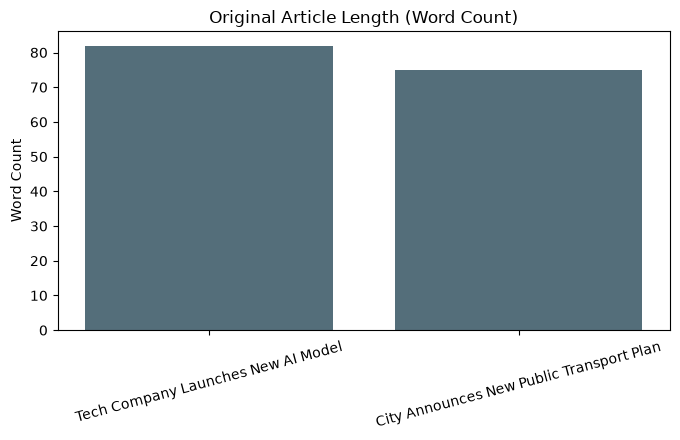

In [10]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(news_df["title"], news_df["num_words"], color="#546E7A")
ax.set_ylabel("Word Count")
ax.set_title("Original Article Length (Word Count)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

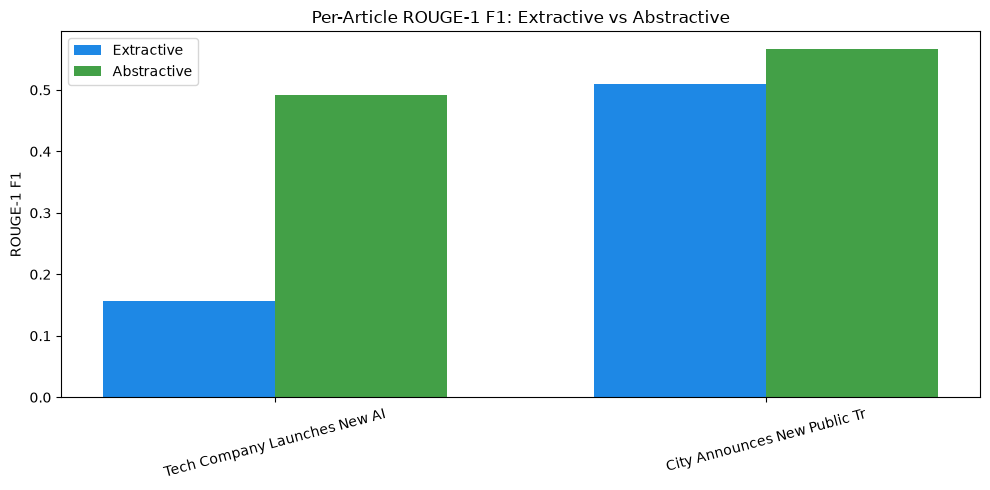

In [11]:
if scorer is not None and not results_df.empty:
    titles = news_df["title"].tolist()
    ext = results_df[results_df["Method"] == "Extractive"].set_index("Article")
    absr = results_df[results_df["Method"] == "Abstractive"].set_index("Article")

    ext_r1 = [ext.loc[t, "ROUGE-1"] if t in ext.index else np.nan for t in titles]
    abs_r1 = [absr.loc[t, "ROUGE-1"] if t in absr.index else np.nan for t in titles]

    x = np.arange(len(titles))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - width / 2, ext_r1, width, label="Extractive", color="#1E88E5")
    ax.bar(x + width / 2, abs_r1, width, label="Abstractive", color="#43A047")
    ax.set_xticks(x)
    ax.set_xticklabels([t[:28] for t in titles], rotation=15)
    ax.set_ylabel("ROUGE-1 F1")
    ax.set_title("Per-Article ROUGE-1 F1: Extractive vs Abstractive")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[SKIPPED] No ROUGE scores available to plot.")

,ROUGE-1,ROUGE-2,ROUGE-L
Method,,,
Abstractive,0.529,0.263,0.393
Extractive,0.334,0.122,0.274


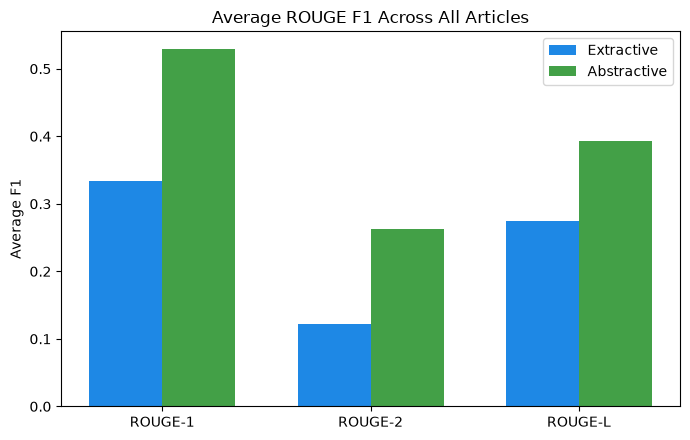

In [12]:
if scorer is not None and not results_df.empty:
    avg_df = results_df.groupby("Method")[["ROUGE-1", "ROUGE-2", "ROUGE-L"]].mean().round(3)
    display(avg_df)

    x = np.arange(3)
    width = 0.35
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(x - width / 2, avg_df.loc["Extractive"], width, label="Extractive", color="#1E88E5")
    ax.bar(x + width / 2, avg_df.loc["Abstractive"], width, label="Abstractive", color="#43A047")
    ax.set_xticks(x)
    ax.set_xticklabels(["ROUGE-1", "ROUGE-2", "ROUGE-L"])
    ax.set_ylabel("Average F1")
    ax.set_title("Average ROUGE F1 Across All Articles")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("[SKIPPED] No average ROUGE scores available to plot.")

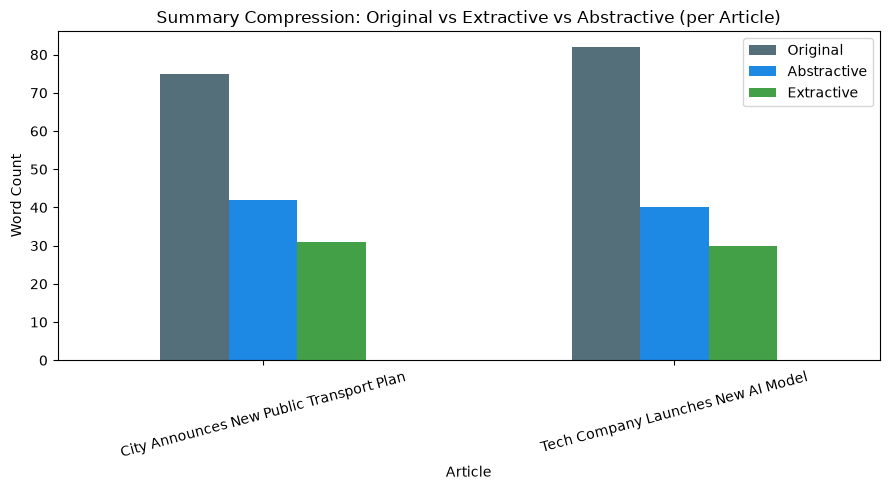

In [13]:
if not results_df.empty:
    pivot = results_df.pivot(index="Article", columns="Method", values="Summary_Word_Count")
    pivot["Original"] = news_df.set_index("title")["num_words"]
    pivot = pivot[["Original"] + [c for c in pivot.columns if c != "Original"]]

    ax = pivot.plot(kind="bar", figsize=(9, 5), color=["#546E7A", "#1E88E5", "#43A047"][:len(pivot.columns)])
    ax.set_ylabel("Word Count")
    ax.set_title("Summary Compression: Original vs Extractive vs Abstractive (per Article)")
    ax.tick_params(axis="x", rotation=15)
    ax.legend(title="")
    plt.tight_layout()
    plt.show()
else:
    print("[SKIPPED] No summaries available to compare.")

### Step 9: Final Mini-Project Results Table

In [14]:
final_results = results_df.rename(columns={
    "Original_Word_Count": "Original word count",
    "Summary_Word_Count": "Summary word count",
    "Compression_%": "Compression percentage",
})[["Article", "Method", "Original word count", "Summary word count",
    "Compression percentage", "ROUGE-1", "ROUGE-2", "ROUGE-L"]]
final_results

,Article,Method,Original word count,Summary word count,Compression percentage,ROUGE-1,ROUGE-2,ROUGE-L
0,Tech Company Launches New AI Model,Extractive,82,30,63.4,0.157,0.000,0.157
1,Tech Company Launches New AI Model,Abstractive,82,40,51.2,0.491,0.182,0.386
2,City Announces New Public Transport Plan,Extractive,75,31,58.7,0.510,0.245,0.392
3,City Announces New Public Transport Plan,Abstractive,75,42,44.0,0.567,0.345,0.400


### Conclusion
This mini-project extended the single-article summarization pipeline of Experiment 9 into a small, modular system that processes a dataset of news articles end-to-end: cleaning, extractive summarization, abstractive summarization, and ROUGE-based evaluation, all stored in structured DataFrames and summarized visually. The results show that extractive and abstractive summarization offer different, complementary trade-offs across a dataset just as they did for a single article, reinforcing that the choice of method should depend on whether faithfulness to the source or fluent, concise phrasing matters more for the intended use case.